# Minimal Example: sdO limb-darkening

In this example script, we'll reproduce Figure 2 from the v2.5 release paper ([Jones et al. 2026](http://phoebe-project.org/publications/2026Jones+)).

Let's first make sure we have the latest version of PHOEBE 2.5 installed (uncomment this line if running in an online notebook session such as colab).

In [1]:
#!pip install -I "phoebe>=2.5"

In [1]:
import phoebe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams["font.size"] = 18
matplotlib.rcParams['figure.figsize'] = [12.8,6.4]
#rcParams["text.latex.preamble"] = r"\usepackage{cmbright}"
matplotlib.rcParams["savefig.dpi"] = 100
from phoebe.atmospheres import models
from phoebe.atmospheres.passbands import InterpQuery


Load passband of choice

In [2]:
pb=phoebe.get_passband('SDSS:gprime')


Choose a model and get its Imus and LD coeffs

In [3]:
Teff=70000
Logg=6.
loghefrac=-0.97

model_mus = models.TMAPsdOModelAtmosphere.mus
Teffs=Teff*np.ones(len(model_mus))
loggs=Logg*np.ones(len(model_mus))
loghefracs=loghefrac*np.ones(len(model_mus))


query_pts = np.ascontiguousarray(np.array([Teffs,loggs,loghefracs,model_mus]).T)

query_table=InterpQuery(cols=['teffs','loggs','loghefracs','mus'],pts=np.c_[query_pts])

Imu=pb.interpolate_imus(query_table,atm=models.TMAPsdOModelAtmosphere,ldatm='tmap_sdO').get_interpolated_values()


mus=np.linspace(0.0000001,1.0,1000)
Teffs=Teff*np.ones(len(mus))
loggs=Logg*np.ones(len(mus))
loghefracs=loghefrac*np.ones(len(mus))
query_pts=np.ascontiguousarray(np.array([Teffs,loggs,loghefracs,mus]).T)
query_table = InterpQuery(cols=['teffs','loggs','loghefracs','mus'],pts=query_pts)

powerImus=pb.interpolate_imus(query_table,atm=models.TMAPsdOModelAtmosphere,ldatm=models.TMAPsdOModelAtmosphere, ld_func='power').get_interpolated_values()
linImus=pb.interpolate_imus(query_table,atm=models.TMAPsdOModelAtmosphere,ldatm=models.TMAPsdOModelAtmosphere, ld_func='linear').get_interpolated_values()
sqrtImus=pb.interpolate_imus(query_table,atm=models.TMAPsdOModelAtmosphere,ldatm=models.TMAPsdOModelAtmosphere, ld_func='square_root').get_interpolated_values()
quadImus=pb.interpolate_imus(query_table,atm=models.TMAPsdOModelAtmosphere,ldatm=models.TMAPsdOModelAtmosphere, ld_func='quadratic').get_interpolated_values()
logImus=pb.interpolate_imus(query_table,atm=models.TMAPsdOModelAtmosphere,ldatm=models.TMAPsdOModelAtmosphere, ld_func='logarithmic').get_interpolated_values()


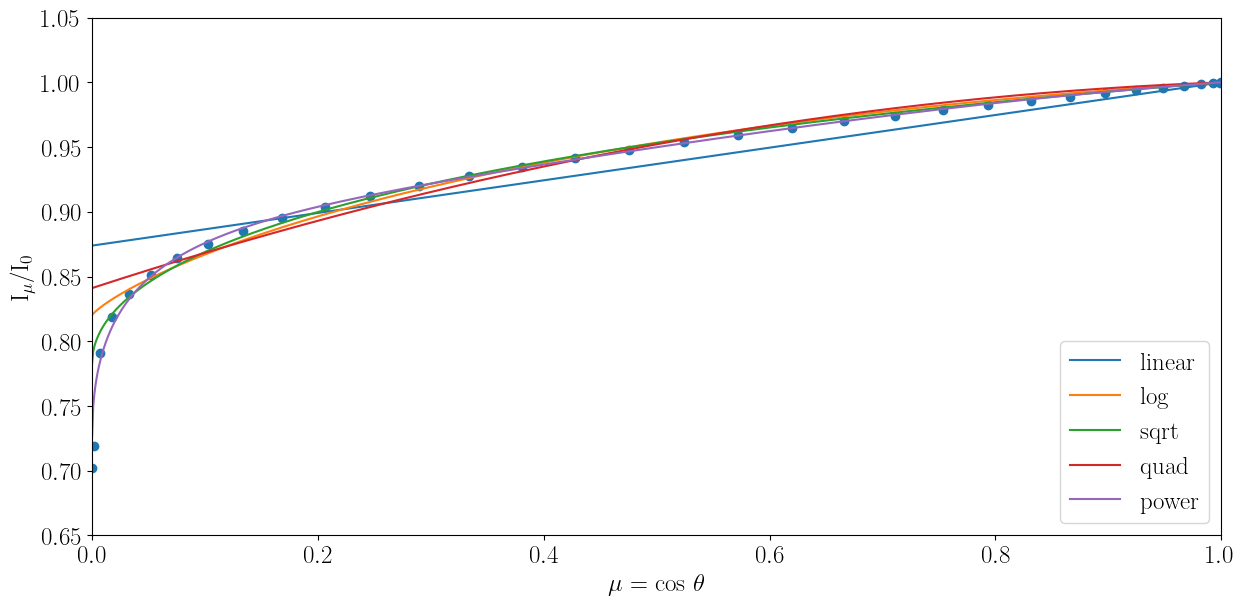

In [4]:
plt.plot(mus,linImus/linImus[-1],label='linear')
plt.plot(mus,logImus/linImus[-1],label="log")
plt.plot(mus,sqrtImus/linImus[-1],label="sqrt")
plt.plot(mus,quadImus/linImus[-1],label="quad")
plt.plot(mus,powerImus/linImus[-1],label="power")
plt.scatter(model_mus,Imu/Imu[-1])
plt.legend(loc='lower right')
plt.xlim([0.,1.])
plt.ylim([0.65,1.05])
plt.ylabel(r'I$_\mu$/I$_0$')
plt.xlabel(r"$\mu$ = cos $\theta$")
plt.tight_layout()
